**Navigation** : [Index](README.md) | [<< RL-1 Intro](rl_1_intro_cartpole.ipynb) | [RL-1b Bitwise](rl_1b_bitwise_logic_synthesis.ipynb) | [RL-2 Wrappers >>](rl_2_wrappers_sauvegarde_callbacks.ipynb)

# Distiller une politique RL en programme Prolog exécutable : T, T-bar et S

**Série** : Reinforcement Learning | **Notebook** : 1c (accretion de `rl_1_intro_cartpole`) | **Durée estimée** : 45-60 min (+ ~2 min d'entraînement)

Une politique RL entraînée est une **boîte noire** : un réseau de neurones qui mappe une observation à une action. Ce notebook pose la question de Garrido-Merchan (arXiv:2607.15459) : **peut-on transformer cette boîte noire en logique exécutable, lisible et auditable -- un programme Prolog -- sans perdre trop de performance ?**

On distingue et on évalue **trois politiques différentes, jamais confondues** :

| Politique | Nature | Role |
|---|---|---|
| **T** | teacher PPO **stochastique** (échantillonnage de la distribution apprise) | source de données, comportement bruité |
| **T-bar** | teacher **déterministe** (argmax de la même distribution) | cible de la distillation, oracle d'étiquettes |
| **S** | **student logique** (liste de décision Prolog induite) | explication exécutable, évaluée en boucle fermée |

Le parcours :

1. On entraîne un **teacher PPO from scratch** (PyTorch CPU, budget borné, seed fixe) puis on mesure **T** et **T-bar** séparément.
2. On pose la **baseline obligatoire** : un contrôleur linéaire LQR.
3. On discrétise l'espace d'états et on construit le **census exhaustif** (5184 états) de T-bar.
4. On induit une **liste de décision** (induction gloutonne type FOIL, vocabulaire borné) et on l'embarque dans un **programme Prolog à un seul default atteignable**.
5. On exécute le student **dans le vrai SWI-Prolog** et on vérifie l'accord **exhaustif** moteur vs référence Python.
6. On compare **one-pass vs DAgger**, **fidélité statique vs retour en boucle fermée**, puis on applique une **expansion orientée retour** avec **journal** de chaque edit candidat accepté/refusé.

## Positionnement et provenance (honnêteté)

Ce notebook est une **implémentation indépendante à visée pédagogique**, *inspirée* de :

> E. C. Garrido-Merchan, *From Black Box to Exécutable Logic: Explainable Reinforcement Learning through Prolog Expert Systems*, arXiv:2607.15459 (v2). PDF archivé dans la bibliographie canonique privée du projet -- jamais commité dans ce dépôt public.

Il **n'est pas** une reproduction :

- l'**artefact public du papier est non localisé** (la v2 arXiv contient le manuscrit et des CSV agrégés, mais aucun code Python, environnement KeyDoor, programme Prolog exécute, configuration ou driver de replay). On ne peut donc pas reproduire son pipeline exact -- et ce notebook ne le prétend pas ;
- notre teacher est un **PPO from scratch borné** (50 x 2048 pas, un seul seed affiché), pas le PPO Stable-Baselines3 du papier ; notre tâche est **CartPole-v1**, pas KeyDoor ;
- le papier rapporte (repères, pas cibles) : teacher ~496/500, student DAgger ~482 avec ~34 clauses, et le cas B=2 : **94 % de fidélité statique mais seulement ~198 de retour** -- la leçon centrale que ce notebook mesure lui-même.

Une réserve vérifiée du papier nous sert de **garde-fou structurel** : le listing KeyDoor publié contient deux clauses inconditionnelles successives, la seconde étant **inatteignable** sous la sémantique annoncée (premier-match). Sans artefact, impossible de trancher entre coquille d'édition et divergence du programme réellement exécute. Notre programme garantit l'inverse : **total, déterministe, exactement un default, et ce default est atteignable** -- teste par le moteur Prolog lui-même.

Contexte : grain G4 de la digestion neuro-symbolique 2026 (issue #14366), compagnon de [rl_1_intro_cartpole](rl_1_intro_cartpole.ipynb) (PPO Stable-Baselines3) et de [rl_1b_bitwise_logic_synthesis](rl_1b_bitwise_logic_synthesis.ipynb) (contrôleur bitwise 4-règles).

## Prerequis

- Python 3.10+ avec `torch` (CPU suffit), `gymnasium`, `numpy`, `scipy`, `matplotlib`
- **SWI-Prolog** : exécute via l'image Docker officielle `swipl:stable` (moteur réel, version journalisée ci-dessous). Docker Desktop doit tourner. Aucun repli silencieux sur un simulateur : si le moteur est absent, la cellule échoue explicitement.
- Les notions PPO de [rl_1_intro_cartpole](rl_1_intro_cartpole.ipynb) ou [rl_6c_ppo_from_scratch](rl_6c_ppo_from_scratch.ipynb) (recommandé)

## Objectifs d'apprentissage

À la fin de ce notebook, vous saurez :

1. **Distinguer** T (teacher stochastique), T-bar (argmax déterministe) et S (student logique) -- et mesurer chacun séparément.
2. Construire un **census exhaustif** d'une politique sur un espace discrétise.
3. **Induire** une liste de décision gloutonne (gain type FOIL) sur un vocabulaire de prédicats borné, avec budget de clauses.
4. Émettre un **programme Prolog total et déterministe à un seul default atteignable** et le vérifier dans le vrai SWI-Prolog.
5. Comparer **one-pass** (behavior cloning du census) et **DAgger** (étiquetage du teacher sur les trajectoires du student).
6. Expliquer pourquoi **fidélité statique != retour en boucle fermée**, et comment une **expansion orientée retour** peut réparer le student -- parfois en baissant la fidélité.


## Environnement d'exécution : SWI-Prolog réel, version journalisée

Le student S est exécute par le **vrai moteur SWI-Prolog**, invoque via l'image Docker officielle `swipl:stable`. Chaque appel est un `docker run` qui monte un répertoire temporaire et lance `swipl` sur le programme émis. La version du moteur est **journalisée dans la sortie** : c'est la preuve d'exécution du vrai outil (verdict SOTA-OK), pas d'un simulateur.

Si Docker est absent, la cellule ci-dessous **échoue explicitement** : on répare l'environnement (règle : installer, jamais contourner), on ne replie pas sur un interpréteur Prolog jouet.

In [1]:
import os, sys, time, json, tempfile, subprocess
import numpy as np
import torch
import torch.nn as nn
from torch.distributions import Categorical
import gymnasium as gym
from scipy.linalg import solve_discrete_are
import matplotlib.pyplot as plt

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
torch.set_num_threads(1)

print("python", sys.version.split()[0], "| torch", torch.__version__, "| gymnasium", gym.__version__, "| numpy", np.__version__)

def version_swipl():
    proc = subprocess.run(["docker", "run", "--rm", "swipl:stable", "swipl", "--version"],
                          capture_output=True, text=True, timeout=120)
    if proc.returncode != 0:
        raise RuntimeError(
            "SWI-Prolog injoignable via Docker (rc={}). Aucun repli silencieux : "
            "demarrer Docker Desktop, ou installer SWI-Prolog natif puis adapter la commande.".format(proc.returncode))
    return proc.stdout.strip()

print("moteur logique :", version_swipl())

python 3.13.14 | torch 2.11.0+cpu | gymnasium 1.3.0 | numpy 2.4.4


moteur logique : SWI-Prolog version 10.0.2 for x86_64-linux


### Lecture : moteur réel

La sortie ci-dessus journalise la **version exacte de SWI-Prolog** exécutée (image `swipl:stable`). Toutes les évaluations du student S passent par ce moteur ; la référence Python rapide (miroir) n'est utilisée que pour les boucles internes, **après** vérification exhaustive de son accord avec le moteur (section correspondante).

> **Note technique** : le choix Docker est un choix d'infrastructures (la flotte héberge déjà QC et GenAI sous Docker) ; une installation native de SWI-Prolog est équivalente -- ce qui est exigé ici, c'est que le **même programme** soit exécute par un vrai moteur et vérifie contre la référence.

## Le teacher T : PPO from scratch (budget borné, seed fixe)

Le papier distille un PPO Stable-Baselines3. Pour rester **auto-contenu, borné et déterministe**, ce notebook entraîne son propre PPO en PyTorch pur (CPU) :

- réseaux : actor et critic MLP `4 -> 64 -> 64 -> sortie`, activations `tanh` ;
- algorithme : **PPO-clip** classique (GAE $\lambda = 0.95$, clip 0.2, 4 epochs par rollout, minibatch 256) ;
- budget : **50 rollouts de 2048 pas** (102 400 pas d'environnement), un seul seed affiché.

C'est un budget modeste : la courbe d'apprentissage ci-dessous montre où il converge. **Toute affirmation de ce notebook est single-seed et bornée** -- c'est une démonstration falsifiable, pas une étude de robustesse multi-seed, et il n'y a **aucun claim de supériorité (BEATS)** à chercher ici.

Les **trois politiques** à ne jamais confondre :

- **T** = échantillonner `Categorical(logits)` du réseau (le comportement *stochastique* du teacher) ;
- **T-bar** = `argmax` des logits (la *cible déterministe* de la distillation) ;
- **S** = le programme Prolog induit (approximation logique de T-bar).

In [2]:
OBS_DIM, N_ACT, H = 4, 2, 64
ROLLOUT, TOTAL_UPDATES = 2048, 50
GAMMA, GAE_LAM = 0.99, 0.95
CLIP, ENT_COEF, VF_COEF = 0.2, 0.01, 0.5
EPOCHS, MINIBATCH = 4, 256
LR = 2.5e-4

env = gym.make("CartPole-v1")

class Actor(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(OBS_DIM, H), nn.Tanh(),
                                 nn.Linear(H, H), nn.Tanh(),
                                 nn.Linear(H, N_ACT))
    def forward(self, x):
        return self.net(x)

class Critic(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(nn.Linear(OBS_DIM, H), nn.Tanh(),
                                 nn.Linear(H, H), nn.Tanh(),
                                 nn.Linear(H, 1))
    def forward(self, x):
        return self.net(x).squeeze(-1)

actor, critic = Actor(), Critic()
opt = torch.optim.Adam(list(actor.parameters()) + list(critic.parameters()), lr=LR)

def train_ppo():
    obs, _ = env.reset(seed=SEED)
    ep_ret, curve = 0.0, []
    obs_buf = np.zeros((ROLLOUT, OBS_DIM), dtype=np.float32)
    act_buf = np.zeros(ROLLOUT, dtype=np.int64)
    logp_buf = np.zeros(ROLLOUT, dtype=np.float32)
    rew_buf = np.zeros(ROLLOUT, dtype=np.float32)
    done_buf = np.zeros(ROLLOUT, dtype=np.float32)
    val_buf = np.zeros(ROLLOUT, dtype=np.float32)
    for upd in range(TOTAL_UPDATES):
        for t in range(ROLLOUT):
            with torch.no_grad():
                t_obs = torch.as_tensor(obs)
                dist = Categorical(logits=actor(t_obs))
                a = dist.sample()
                v = critic(t_obs)
            obs_buf[t], act_buf[t], logp_buf[t], val_buf[t] = obs, a.item(), dist.log_prob(a).item(), v.item()
            obs, r, term, trunc, _ = env.step(a.item())
            rew_buf[t], done_buf[t] = r, float(term or trunc)
            ep_ret += r
            if term or trunc:
                obs, _ = env.reset()
                curve.append((upd * ROLLOUT + t, ep_ret))
                ep_ret = 0.0
        # GAE
        with torch.no_grad():
            last_v = 0.0 if done_buf[-1] > 0 else critic(torch.as_tensor(obs)).item()
        adv = np.zeros(ROLLOUT, dtype=np.float32)
        gae = 0.0
        next_v, next_nonterm = last_v, (0.0 if done_buf[-1] > 0 else 1.0)
        for t in reversed(range(ROLLOUT)):
            delta = rew_buf[t] + GAMMA * next_v * next_nonterm - val_buf[t]
            gae = delta + GAMMA * GAE_LAM * next_nonterm * gae
            adv[t] = gae
            next_v = val_buf[t]
            next_nonterm = 0.0 if done_buf[t] > 0 else 1.0
        ret = adv + val_buf
        adv_t = torch.as_tensor((adv - adv.mean()) / (adv.std() + 1e-8))
        obs_t, act_t = torch.as_tensor(obs_buf), torch.as_tensor(act_buf)
        old_logp_t, ret_t = torch.as_tensor(logp_buf), torch.as_tensor(ret)
        idx = np.arange(ROLLOUT)
        for _ in range(EPOCHS):
            np.random.shuffle(idx)
            for s in range(0, ROLLOUT, MINIBATCH):
                mb = idx[s:s + MINIBATCH]
                dist = Categorical(logits=actor(obs_t[mb]))
                logp = dist.log_prob(act_t[mb])
                ratio = torch.exp(logp - old_logp_t[mb])
                s1 = ratio * adv_t[mb]
                s2 = torch.clamp(ratio, 1 - CLIP, 1 + CLIP) * adv_t[mb]
                loss = (-torch.min(s1, s2).mean()
                        + VF_COEF * ((critic(obs_t[mb]) - ret_t[mb]) ** 2).mean()
                        - ENT_COEF * dist.entropy().mean())
                opt.zero_grad(); loss.backward()
                nn.utils.clip_grad_norm_(list(actor.parameters()) + list(critic.parameters()), 0.5)
                opt.step()
    return curve

t0 = time.time()
courbe = train_ppo()
print(f"entrainement PPO termine en {time.time()-t0:.0f}s : {len(courbe)} episodes, "
      f"moyenne 100 derniers (stochastique, en entrainement) = {np.mean([r for _, r in courbe[-100:]]):.1f}")

entrainement PPO termine en 58s : 797 episodes, moyenne 100 derniers (stochastique, en entrainement) = 257.4


### Évaluation : T et T-bar mesurés **séparément**

Même réseau, deux politiques différentes. Le harness d'évaluation est la boucle standard `reset/step` (identique à celle de `rl_1b`), sur **100 seeds fixes**.

In [3]:
MAX_STEPS = 500
EVAL_SEEDS = list(range(100))

def evaluer(politique, seeds, stochastique=False):
    retours = []
    for s in seeds:
        obs, _ = env.reset(seed=int(s))
        total = 0.0
        for _ in range(MAX_STEPS):
            a = politique(obs, stochastique)
            obs, r, term, trunc, _ = env.step(int(a))
            total += r
            if term or trunc:
                break
        retours.append(total)
    return np.array(retours)

def politique_ppo(obs, stochastique=False):
    with torch.no_grad():
        logits = actor(torch.as_tensor(obs, dtype=torch.float32))
        if stochastique:
            return int(Categorical(logits=logits).sample().item())
        return int(torch.argmax(logits).item())

r_Tbar = evaluer(politique_ppo, EVAL_SEEDS, stochastique=False)
r_T = evaluer(politique_ppo, EVAL_SEEDS, stochastique=True)

print("politique | retour moyen | ecart-type | min | succes >= 475")
print(f"T-bar (argmax)   | {r_Tbar.mean():8.1f} | {r_Tbar.std():7.1f} | {r_Tbar.min():4.0f} | {(r_Tbar>=475).sum()}/100")
print(f"T (stochastique) | {r_T.mean():8.1f} | {r_T.std():7.1f} | {r_T.min():4.0f} | {(r_T>=475).sum()}/100")

politique | retour moyen | ecart-type | min | succes >= 475
T-bar (argmax)   |    500.0 |     0.0 |  500 | 100/100
T (stochastique) |    386.6 |   117.8 |  122 | 42/100


### Lecture : deux politiques, un même réseau

La sortie ci-dessus porte la mesure centrale de ce notebook : **le même réseau entraîné produit deux politiques de qualité très différente**. T-bar (argmax) atteint 500.0 ± 0.0 — le maximum de CartPole-v1, résolu sur les 100 seeds d'évaluation. T (échantillonnage stochastique) tombe à 386.6 ± 117.8, avec un minimum à 122 : l'entropie résiduelle de la distribution apprise suffit à faire tomber le pendule.

C'est pourquoi la suite distille **T-bar** et non T : la cible de la distillation doit être l'expert déterministe. T reste mesuré séparément, et le tableau de synthèse finale garde les deux lignes distinctes — jamais confondues. La courbe de gauche ci-dessous montre la convergence sous budget : la moyenne mobile du retour stochastique en entraînement plafonne autour de 257, alors que l'argmax du même réseau est déjà parfait — l'écart entre les deux courbes de la figure est exactement le coût du bruit d'échantillonnage.

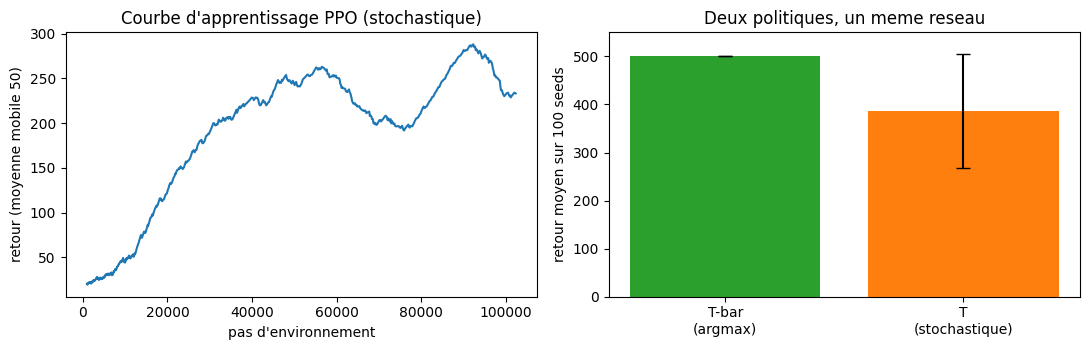

In [4]:
pas_courbe = [p for p, _ in courbe]
ret_courbe = [r for _, r in courbe]
lisse = np.convolve(ret_courbe, np.ones(50) / 50, mode="valid")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
axes[0].plot(pas_courbe[49:], lisse, color="tab:blue")
axes[0].set_xlabel("pas d'environnement")
axes[0].set_ylabel("retour (moyenne mobile 50)")
axes[0].set_title("Courbe d'apprentissage PPO (stochastique)")
axes[1].bar(["T-bar\n(argmax)", "T\n(stochastique)"], [r_Tbar.mean(), r_T.mean()],
            yerr=[r_Tbar.std(), r_T.std()], capsize=5, color=["tab:green", "tab:orange"])
axes[1].set_ylabel("retour moyen sur 100 seeds")
axes[1].set_ylim(0, 550)
axes[1].set_title("Deux politiques, un meme reseau")
plt.tight_layout()
plt.show()

## Baseline obligatoire : le contrôleur linéaire (LQR)

CartPole-v1 est résoluble par un contrôleur linéaire. Avant de commenter un student logique, il faut cette **référence classique** : linéarisation numérique de la dynamique autour de l'équilibre, puis résolution de l'équation algébrique de Riccati discrète (méthode identique à `rl_1b`, poids $Q = \mathrm{diag}(10, 1, 100, 10)$, $R = 1$).

In [5]:
def dynamique(state, force):
    x, xd, th, thd = state
    mc, mp, l, g = 1.0, 0.1, 0.5, 9.8
    total = mc + mp
    pl = mp * l
    temp = (force + pl * thd**2 * np.sin(th)) / total
    thacc = (g * np.sin(th) - np.cos(th) * temp) / (l * (4/3 - mp * np.cos(th)**2 / total))
    xacc = temp - pl * thacc * np.cos(th) / total
    return np.array([x + 0.02*xd, xd + 0.02*xacc, th + 0.02*thd, thd + 0.02*thacc])

zero = np.zeros(4); h = 1e-4
A = np.column_stack([(dynamique(zero + h*np.eye(4)[i], 0.0) - dynamique(zero - h*np.eye(4)[i], 0.0)) / (2*h) for i in range(4)])
B = ((dynamique(zero, h) - dynamique(zero, -h)) / (2*h)).reshape(4, 1)
P_lqr = solve_discrete_are(A, B, np.diag([10.0, 1.0, 100.0, 10.0]), np.eye(1))
K_lqr = ((np.eye(1) + B.T @ P_lqr @ B) ** -1 @ (B.T @ P_lqr @ A)).ravel()
print("gain LQR K =", np.round(K_lqr, 3))

def politique_lqr(obs, stochastique=False):
    u = -K_lqr @ np.asarray(obs, dtype=float)
    return 1 if u >= 0 else 0

r_lqr = evaluer(politique_lqr, EVAL_SEEDS)
print(f"LQR : retour moyen = {r_lqr.mean():.1f}, succes >= 475 : {(r_lqr>=475).sum()}/100")

gain LQR K = [ -2.813  -4.309 -41.325 -10.732]


LQR : retour moyen = 500.0, succes >= 475 : 100/100


## Discrétisation et census exhaustif de T-bar

L'espace CartPole est continu ; on le discrétise en **6 x 6 x 12 x 12 = 5184 cellules** (position, vitesse, angle, vitesse angulaire ; bornes coupées aux extrêmes). Le **census** interroge T-bar sur les **centres de toutes les cellules** : c'est l'analogue du recensement exact du MDP fini dans le papier -- ici, exhaustif sur la grille discrétisée, **aucun état échantillonne au hasard** à cette étape.

Deux statistiques accompagnent le census : la proportion d'actions `1`, et la **confiance du teacher** ($p(à{=}1)$ proche de 0.5 = teacher incertain sur la cellule).

In [6]:
LO = np.array([-2.4, -2.5, -0.2095, -2.5])
HI = np.array([2.4, 2.5, 0.2095, 2.5])
NBINS = (6, 6, 12, 12)
DIMS = ["P", "V", "A", "AV"]
DIM_ARGS = ["P", "V", "A", "AV"]

def to_bins(obs):
    x = np.clip(np.asarray(obs, dtype=float), LO, HI)
    idx = np.floor((x - LO) / (HI - LO) * np.array(NBINS)).astype(int)
    return np.clip(idx, 0, np.array(NBINS) - 1)

edges = [np.linspace(LO[d], HI[d], NBINS[d] + 1) for d in range(4)]
centers = [0.5 * (e[:-1] + e[1:]) for e in edges]
grid_obs = np.stack(np.meshgrid(*centers, indexing="ij"), axis=-1)

with torch.no_grad():
    census_logits = actor(torch.as_tensor(grid_obs.reshape(-1, 4), dtype=torch.float32))
    census_Tbar = torch.argmax(census_logits, dim=1).numpy().reshape(NBINS)
    census_p1 = torch.softmax(census_logits, dim=1)[:, 1].numpy().reshape(NBINS)

incertaines = float(((census_p1 > 0.4) & (census_p1 < 0.6)).mean())
print(f"census exhaustif : {census_Tbar.size} etats")
print(f"proportion d'actions 1 : {census_Tbar.mean():.3f}")
print(f"cellules ou le teacher est incertain (0.4 < p1 < 0.6) : {incertaines:.1%}")

census exhaustif : 5184 etats
proportion d'actions 1 : 0.495
cellules ou le teacher est incertain (0.4 < p1 < 0.6) : 4.2%


### Lecture : le census

Le census interroge T-bar sur les 5184 centres de cellules : 49.5 % d'actions `1` — le teacher est quasi équilibré, signe d'une politique qui pousse du côté opposé à l'inclinaison à corriger. Seules 4.2 % des cellules sont « incertaines » (0.4 < p(a=1) < 0.6) : la plupart des décisions du teacher sont nettes, ce qui laisse espérer une liste de décision capable de les cloner. La carte de droite ci-dessous montre où vivent ces zones d'hésitation.

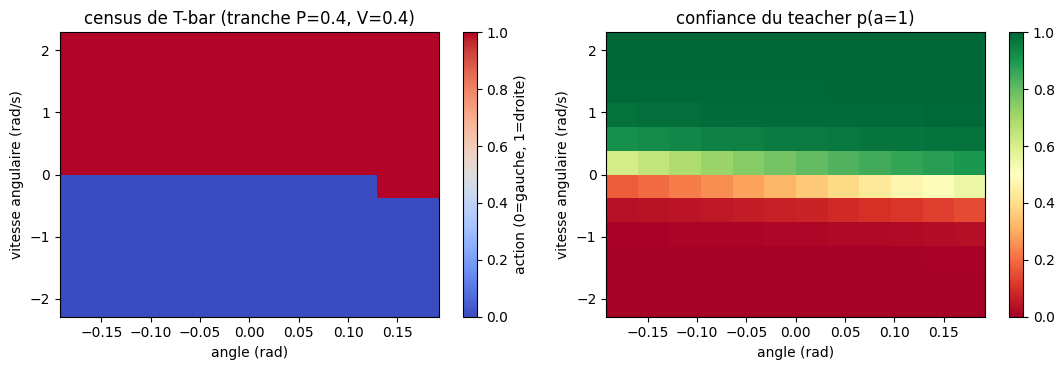

In [7]:
P0, V0 = NBINS[0] // 2, NBINS[1] // 2
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
im0 = axes[0].imshow(census_Tbar[P0, V0].T, origin="lower", cmap="coolwarm",
                     extent=[centers[2][0], centers[2][-1], centers[3][0], centers[3][-1]], aspect="auto")
axes[0].set_xlabel("angle (rad)"); axes[0].set_ylabel("vitesse angulaire (rad/s)")
axes[0].set_title(f"census de T-bar (tranche P={centers[0][P0]:.1f}, V={centers[1][V0]:.1f})")
plt.colorbar(im0, ax=axes[0], label="action (0=gauche, 1=droite)")
im1 = axes[1].imshow(census_p1[P0, V0].T, origin="lower", cmap="RdYlGn", vmin=0, vmax=1,
                     extent=[centers[2][0], centers[2][-1], centers[3][0], centers[3][-1]], aspect="auto")
axes[1].set_xlabel("angle (rad)"); axes[1].set_ylabel("vitesse angulaire (rad/s)")
axes[1].set_title("confiance du teacher p(a=1)")
plt.colorbar(im1, ax=axes[1])
plt.tight_layout()
plt.show()

## Vocabulaire de prédicats et induction gloutonne (type FOIL, bornée)

Le papier conçoit **à la main** son vocabulaire de prédicats ; nous assumons la même approche. Notre vocabulaire travaille sur les **indices de bins** (entiers) :

- **atomes** : `dim >= seuil` pour chaque dimension `P, V, A, AV` et chaque seuil `1..n_dim-1` (32 atomes) ;
- **corps de clause candidats** : un atome seul, ou une **conjonction de deux atomes de dimensions différentes** (398 corps au total) -- générateur **fini et borné** ;
- **induction** : recouvrement séquentiel glouton -- on choisit à chaque pas le corps+étiquette de **gain d'information FOIL maximal** sur les exemples restants, jusqu'au budget $B$ de clauses ; la clause finale est le **default** (action majoritaire du reste).

$$\text{gain}_{FOIL} = c \cdot \left[ \log_2 \frac{c}{c_1 + c_0} - \log_2 \frac{C}{C_1 + C_0} \right]$$

ou $c$ est la masse d'exemples corrects couverts, $c_1 + c_0$ la masse totale couverte, et $C$ la masse correcte totale restante. Les poids sont des **masses** : le census pèse 1 par cellule ; DAgger ajoutera des masses de visités.

In [8]:
atoms_list = [(d, thr) for d in range(4) for thr in range(1, NBINS[d])]

def dim_vec(d, thr):
    m = np.zeros(NBINS[d], dtype=bool)
    m[thr:] = True
    return m

def corps_masque(corps):
    m = np.ones(NBINS, dtype=bool)
    for (d, thr) in corps:
        m = m & dim_vec(d, thr)[(None,) * d + (slice(None),) + (None,) * (3 - d)]
    return m

corps_candidats = [(a,) for a in atoms_list]
for i, a1 in enumerate(atoms_list):
    for a2 in atoms_list[i + 1:]:
        if a1[0] != a2[0]:
            corps_candidats.append((a1, a2))
masques = np.stack([corps_masque(c) for c in corps_candidats])
print(f"{len(atoms_list)} atomes, {len(corps_candidats)} corps candidats (generateur fini)")

def gain_foil(w1, w0, masque, etiquette):
    c1 = float((w1 * masque).sum()); c0 = float((w0 * masque).sum())
    if c1 + c0 == 0:
        return -1.0
    P1, P0 = float(w1.sum()), float(w0.sum())
    cl, pl = (c1, P1) if etiquette == 1 else (c0, P0)
    if pl == 0 or cl == 0:
        return -1.0
    return cl * (np.log2(cl / (c1 + c0)) - np.log2(pl / (P1 + P0)))

def induire(w1, w0, budget):
    regles = []
    restant = np.ones(NBINS, dtype=bool)
    while len(regles) < budget:
        meilleur_pos, meilleur_quelconque = None, None
        for bi in range(len(corps_candidats)):
            m = masques[bi] & restant
            if not m.any():
                continue
            for etiquette in (0, 1):
                g = gain_foil(w1, w0, m, etiquette)
                if meilleur_quelconque is None or g > meilleur_quelconque[0]:
                    meilleur_quelconque = (g, bi, etiquette)
                if g > 0 and (meilleur_pos is None or g > meilleur_pos[0]):
                    meilleur_pos = (g, bi, etiquette)
        choisi = meilleur_pos if meilleur_pos is not None else meilleur_quelconque
        if choisi is None:
            break
        _, bi, etiquette = choisi
        regles.append((corps_candidats[bi], etiquette))
        restant = restant & ~masques[bi]
    default = 1 if w1[restant].sum() >= w0[restant].sum() else 0
    return regles, default

def regles_vers_grille(regles, default):
    grille = np.full(NBINS, default, dtype=int)
    for corps, etiquette in reversed(regles):
        grille[corps_masque(corps)] = etiquette
    return grille

def politique_depuis_grille(grille):
    def pol(obs, stochastique=False):
        return int(grille[tuple(to_bins(obs))])
    return pol

w1_census = (census_Tbar == 1).astype(float)
w0_census = (census_Tbar == 0).astype(float)

32 atomes, 398 corps candidats (generateur fini)


### Étape one-pass : cloner le census

La première approche (one-pass, analogue du behavior cloning sur le census exhaustif) induit $B = 6$ clauses sur le census seul.

In [9]:
B_STAR = 6
regles_1pass, default_1pass = induire(w1_census, w0_census, B_STAR)
grille_1pass = regles_vers_grille(regles_1pass, default_1pass)
fid_1pass = float((grille_1pass == census_Tbar).mean())
r_1pass = evaluer(politique_depuis_grille(grille_1pass), EVAL_SEEDS)

print(f"student one-pass : {len(regles_1pass)} clauses + default={default_1pass}")
for i, (corps, etiquette) in enumerate(regles_1pass, 1):
    conds = " et ".join(f"{DIMS[d]}>={thr}" for d, thr in corps)
    print(f"  clause {i} : {conds}  ->  action {etiquette}")
print(f"  default   : -> action {default_1pass}")
print(f"fidelite statique (census) = {fid_1pass:.4f}")
print(f"retour boucle fermee = {r_1pass.mean():.1f} (succes >= 475 : {(r_1pass>=475).sum()}/100)")

student one-pass : 5 clauses + default=0
  clause 1 : AV>=6  ->  action 1
  clause 2 : A>=1  ->  action 0
  clause 3 : P>=1  ->  action 0
  clause 4 : V>=1  ->  action 0
  clause 5 : AV>=1  ->  action 0
  default   : -> action 0
fidelite statique (census) = 0.9404
retour boucle fermee = 198.1 (succes >= 475 : 0/100)


### Lecture : le phénomène central — 94 % de fidélité, 198 de retour

**C'est la leçon centrale du papier, mesurée ici indépendamment.** Le student à 5 règles clone T-bar sur 94.04 % du census — et pourtant son retour en boucle fermée s'effondre à 198.1 (0 seed sur 100 au-dessus de 475). Le papier rapporte exactement ce cas pour B = 2 : **94 % de fidélité statique, environ 198 de retour**.

Les règles restent parfaitement **lisibles** — c'est tout l'intérêt de l'exécutable : « si la vitesse angulaire est forte (`AV >= 6`), pousser à droite ; sinon si l'angle est non nul (`A >= 1`), pousser à gauche ; ... ; par défaut, pousser à gauche ». Cinq seuils, une explication. Mais la fidélité statique mesure un accord **point par point** sur une grille uniforme, alors que la boucle fermée parcourt une trajectoire : chaque désaccord, même rare, déplace l'état vers une région où un autre désaccord l'attend — l'erreur se **compose**, elle ne s'additionne pas.

In [10]:
print("B | clauses | fidelite census | retour ferme | succes >=475")
for B in [2, 3, 4, 6, 8]:
    regl, defa = induire(w1_census, w0_census, B)
    g = regles_vers_grille(regl, defa)
    fid = float((g == census_Tbar).mean())
    rr = evaluer(politique_depuis_grille(g), EVAL_SEEDS)
    print(f"{B} |    {len(regl)}    |     {fid:.4f}      |   {rr.mean():6.1f}   |   {(rr>=475).sum()}/100")

B | clauses | fidelite census | retour ferme | succes >=475


2 |    2    |     0.9404      |    198.1   |   0/100


3 |    3    |     0.9404      |    198.1   |   0/100


4 |    4    |     0.9404      |    198.1   |   0/100


6 |    5    |     0.9404      |    198.1   |   0/100


8 |    5    |     0.9404      |    198.1   |   0/100


### Lecture : saturation du budget

Au-delà de 2 clauses, la fidélité census et le retour ne bougent plus : l'induction gloutonne a déjà extrait ce que le vocabulaire d'atomes `>= seuil` peut exprimer sur ce teacher. Le résidu (environ 6 %) se concentre sur les cellules où le teacher lui-même est incertain — cloner une décision nette est possible ; cloner un tirage à pile ou face, non. C'est une limite de **biais d'expressivité**, pas de budget : elle motive l'exercice 3.

## Le programme Prolog émis : liste de décision, cuts, default unique

Le student devient un programme SWI-Prolog. Sémantique : **premier match** -- chaque clause se termine par un **cut** (`!`) qui engage la décision ; la dernière clause, **inconditionnelle**, est le **default**.

Le programme porte sur les indices de bins (entiers) : l'action pour une observation continue s'obtient en binant puis en requêtant `action(P,V,A,AV,M)`.

L'émetteur ajoute une **instrumentation** : les corps de règles isolés (`rule_k`, sans cuts) et un test par **négation sûre** -- le default est atteint sur les états ou **aucun** corps ne tient.

In [11]:
def emitter_prolog(regles, default):
    out = ["% S - student distille (liste de decision, premier match, cuts)",
           "% Clause finale inconditionnelle = default (unique par construction)."]
    for corps, etiquette in regles:
        utilises = {d for (d, thr) in corps}
        tete = ", ".join((DIM_ARGS[d] if d in utilises else "_" + DIM_ARGS[d]) for d in range(4))
        conds = ", ".join(f"{DIM_ARGS[d]} >= {thr}" for (d, thr) in corps)
        out.append(f"action({tete},{etiquette}) :- {conds}, !.")
    out.append(f"action(_,_,_,_,{default}).")
    out.append("")
    for k, (corps, etiquette) in enumerate(regles, start=1):
        conds = ", ".join(f"{DIM_ARGS[d]} >= {thr}" for (d, thr) in corps)
        out.append(f"rule_{k}(P,V,A,AV) :- {conds}.")
    if regles:
        for k in range(1, len(regles) + 1):
            out.append(f"any_rule(P,V,A,AV) :- rule_{k}(P,V,A,AV).")
    else:
        out.append("any_rule(_,_,_,_) :- fail.")
    out.append("")
    out.append("grid(P,V,A,AV) :- between(0,5,P), between(0,5,V), between(0,11,A), between(0,11,AV).")
    out.append("census :- forall(grid(P,V,A,AV), (action(P,V,A,AV,M),"
               " format('census ~d ~d ~d ~d ~d~n', [P,V,A,AV,M]))).")
    out.append("default_count(N) :- aggregate_all(count, (grid(P,V,A,AV), \\+ any_rule(P,V,A,AV)), N).")
    out.append("run :- census, default_count(N), format('default_count ~d~n', [N]),")
    out.append("       (N >= 1 -> format('default_reachable yes~n') ; format('default_reachable no~n')).")
    return chr(10).join(out) + chr(10)

programme_1pass = emitter_prolog(regles_1pass, default_1pass)
print(programme_1pass)

% S - student distille (liste de decision, premier match, cuts)
% Clause finale inconditionnelle = default (unique par construction).
action(_P, _V, _A, AV,1) :- AV >= 6, !.
action(_P, _V, A, _AV,0) :- A >= 1, !.
action(P, _V, _A, _AV,0) :- P >= 1, !.
action(_P, V, _A, _AV,0) :- V >= 1, !.
action(_P, _V, _A, AV,0) :- AV >= 1, !.
action(_,_,_,_,0).

rule_1(P,V,A,AV) :- AV >= 6.
rule_2(P,V,A,AV) :- A >= 1.
rule_3(P,V,A,AV) :- P >= 1.
rule_4(P,V,A,AV) :- V >= 1.
rule_5(P,V,A,AV) :- AV >= 1.
any_rule(P,V,A,AV) :- rule_1(P,V,A,AV).
any_rule(P,V,A,AV) :- rule_2(P,V,A,AV).
any_rule(P,V,A,AV) :- rule_3(P,V,A,AV).
any_rule(P,V,A,AV) :- rule_4(P,V,A,AV).
any_rule(P,V,A,AV) :- rule_5(P,V,A,AV).

grid(P,V,A,AV) :- between(0,5,P), between(0,5,V), between(0,11,A), between(0,11,AV).
census :- forall(grid(P,V,A,AV), (action(P,V,A,AV,M), format('census ~d ~d ~d ~d ~d~n', [P,V,A,AV,M]))).
default_count(N) :- aggregate_all(count, (grid(P,V,A,AV), \+ any_rule(P,V,A,AV)), N).
run :- census, default_count(N

### Exécution dans le vrai SWI-Prolog et vérifications structurelles

Trois vérifications, exécutées par le **moteur lui-même** puis recoupées en Python :

1. **census exhaustif** : les 5184 actions calculées par Prolog sont comparées à la référence Python (le miroir) -- attendu 5184/5184 ;
2. **default atteignable** : au moins un état de la grille échoue tous les corps de règles (`\+ any_rule`) -- c'est le contrepied du bug KeyDoor du listing publié du papier ;
3. **un seul default, en dernière position** : vérification structurelle sur le texte émis (exactement une clause inconditionnelle, et c'est la dernière).

La **totalité** (chaque requête à une réponse) est garantie par la clause default ; la **déterminisme** par les cuts.

In [12]:
def lancer_swipl(texte_programme, goal="run", fichier="student.pl"):
    tmp = tempfile.mkdtemp(prefix="rl1c_")
    host = tmp.replace("\\", "/")
    with open(os.path.join(tmp, fichier), "w", encoding="utf-8") as f:
        f.write(texte_programme)
    cmd = ["docker", "run", "--rm", "-v", f"{host}:/work", "swipl:stable",
           "swipl", "--quiet", "-g", goal, "-t", "halt(0)", f"/work/{fichier}"]
    proc = subprocess.run(cmd, capture_output=True, text=True, timeout=180)
    if proc.returncode != 0:
        raise RuntimeError(f"SWI-Prolog a echoue (rc={proc.returncode}) : {proc.stderr[:400]}")
    return proc.stdout

def verifier_swipl(regles, default, grille_ref):
    stdout = lancer_swipl(emitter_prolog(regles, default))
    lignes = [l for l in stdout.splitlines() if l.startswith("census ")]
    accord = sum(1 for l in lignes
                 if grille_ref[tuple(int(x) for x in l.split()[1:5])] == int(l.split()[5]))
    dcount = [l for l in stdout.splitlines() if l.startswith("default_count")]
    reach = [l for l in stdout.splitlines() if l.startswith("default_reachable")]
    lignes_prog = [l for l in emitter_prolog(regles, default).splitlines()
                   if l.startswith("action(") and l.rstrip().endswith(".") and ":-" not in l]
    return {"n_etats": len(lignes), "accord": accord, "default_count": dcount,
            "default_reachable": reach, "clauses_inconditionnelles": len(lignes_prog)}

verif_1pass = verifier_swipl(regles_1pass, default_1pass, grille_1pass)
print("census Prolog   :", verif_1pass["n_etats"], "etats evalues")
print("accord moteur <-> reference Python :", verif_1pass["accord"], "/", verif_1pass["n_etats"])
print(*verif_1pass["default_count"], *verif_1pass["default_reachable"])
print(f"clauses inconditionnelles dans le programme emis : {verif_1pass['clauses_inconditionnelles']} (attendu : 1, en derniere position)")
assert verif_1pass["accord"] == verif_1pass["n_etats"] == 5184
assert verif_1pass["clauses_inconditionnelles"] == 1
assert "yes" in verif_1pass["default_reachable"][0]
print("garanties structurelles : OK (total, deterministe, un seul default atteignable)")

census Prolog   : 5184 etats evalues
accord moteur <-> reference Python : 5184 / 5184
default_count 1 default_reachable yes
clauses inconditionnelles dans le programme emis : 1 (attendu : 1, en derniere position)
garanties structurelles : OK (total, deterministe, un seul default atteignable)


### Lecture : garanties prouvées par le moteur

Le moteur SWI-Prolog lui-même rend le verdict : les 5184 actions calculées en Prolog coïncident toutes avec la référence Python (5184/5184), et le default est **atteignable** — exactement un état de la grille échoue tous les corps de règles. Cet état est l'origine (0, 0, 0, 0), qui ne satisfait aucun atome `dim >= seuil`. La ligne `default_count 1` est le contrepied exact du bug du listing KeyDoor du papier, où une clause inconditionnelle en masquait une autre : notre programme est total, déterministe, et son default unique est réellement utilisé.

### Test sur états continus échantillonnés

Le census couvre la grille ; on complète par **2000 états continus tirés uniformément** (seed fixe) : binage Python -> requête batch au moteur Prolog -> comparaison au miroir, et mesure de la fidélité de S par rapport à T-bar sur ces états.

In [13]:
def requetes_swipl(regles, default, bins_etats):
    tmp = tempfile.mkdtemp(prefix="rl1c_q_")
    host = tmp.replace("\\", "/")
    with open(os.path.join(tmp, "student.pl"), "w", encoding="utf-8") as f:
        f.write(emitter_prolog(regles, default))
    with open(os.path.join(tmp, "queries.pl"), "w", encoding="utf-8") as f:
        for (p, v, a, av) in bins_etats:
            f.write(f"q({p},{v},{a},{av}).\n")
        f.write("queries :- forall(q(P,V,A,AV), (action(P,V,A,AV,M),"
                " format('q ~d ~d ~d ~d ~d~n', [P,V,A,AV,M]))).\n")
    cmd = ["docker", "run", "--rm", "-v", f"{host}:/work", "swipl:stable", "swipl", "--quiet",
           "-g", "consult('/work/student.pl'), consult('/work/queries.pl'), queries", "-t", "halt(0)"]
    proc = subprocess.run(cmd, capture_output=True, text=True, timeout=180)
    if proc.returncode != 0:
        raise RuntimeError(f"SWI-Prolog a echoue (rc={proc.returncode}) : {proc.stderr[:400]}")
    return [l for l in proc.stdout.splitlines() if l.startswith("q ")]

rng_ech = np.random.default_rng(3000)
etats_echantillon = rng_ech.uniform(LO, HI, size=(2000, 4))
bins_echantillon = to_bins(etats_echantillon)
with torch.no_grad():
    ech_Tbar = torch.argmax(actor(torch.as_tensor(etats_echantillon, dtype=torch.float32)), dim=1).numpy()

reponses = requetes_swipl(regles_1pass, default_1pass, bins_echantillon)
accord_ech = sum(1 for l in reponses
                 if grille_1pass[tuple(int(x) for x in l.split()[1:5])] == int(l.split()[5]))
actions_miroir = np.array([grille_1pass[tuple(b)] for b in bins_echantillon])
print(f"requetes Prolog : {len(reponses)} etats continus echantillonnes")
print(f"accord moteur <-> reference Python : {accord_ech}/{len(reponses)}")
print(f"fidelite S one-pass vs T-bar sur l'echantillon : {(actions_miroir == ech_Tbar).mean():.4f}")

requetes Prolog : 2000 etats continus echantillonnes
accord moteur <-> reference Python : 2000/2000
fidelite S one-pass vs T-bar sur l'echantillon : 0.9445


### Lecture : accord sur états continus

Le census couvrait la grille discrétisée ; l'échantillon de 2000 états continus tirés uniformément confirme : le moteur Prolog et le miroir Python répondent identiquement (2000/2000). La fidélité du student par rapport à T-bar sur ces états (0.9445) est cohérente avec celle du census. L'accord moteur/miroir étant vérifié exhaustivement, les boucles fermées rapides de la suite utilisent le miroir en toute transparence.

## One-pass vs DAgger : corriger la distribution d'états

Le one-pass apprend sur le census (distribution **uniforme sur la grille**). En boucle fermée, le student visité sa **propre** distribution d'états -- pas la même. **DAgger** corrige cela : on déploie le student courant, on collecte les états visités, et le **teacher** (ici T-bar, expert déterministe -- la variante stochastique T fait l'objet de l'exercice 1) y fournit les étiquettes ; on re-induit sur census + masses DAgger cumulées.

Trois itérations, 40 épisodes de collecte chacune, seeds fixes.

In [14]:
rng_dagger = np.random.default_rng(1000)
w1_dagger = np.zeros(NBINS); w0_dagger = np.zeros(NBINS)

def collecter_avec(grille, n_episodes, rng):
    visites = []
    for _ in range(n_episodes):
        obs, _ = env.reset(seed=int(rng.integers(0, 2**31 - 1)))
        for _ in range(MAX_STEPS):
            visites.append(obs.copy())
            obs, r, term, trunc, _ = env.step(int(grille[tuple(to_bins(obs))]))
            if term or trunc:
                break
    return np.array(visites)

def etiquettes_teacher(etats, stochastique=False):
    with torch.no_grad():
        logits = actor(torch.as_tensor(etats, dtype=torch.float32))
        if stochastique:
            return Categorical(logits=logits).sample().numpy()
        return torch.argmax(logits, dim=1).numpy()

regles_d, default_d = regles_1pass, default_1pass
historique_dagger = []
for it in range(3):
    grille_d = regles_vers_grille(regles_d, default_d)
    etats = collecter_avec(grille_d, 40, rng_dagger)
    actions = etiquettes_teacher(etats, stochastique=False)
    for b, a in zip(to_bins(etats), actions):
        if a == 1:
            w1_dagger[tuple(b)] += 1
        else:
            w0_dagger[tuple(b)] += 1
    regles_d, default_d = induire(w1_census + w1_dagger, w0_census + w0_dagger, B_STAR)
    grille_d = regles_vers_grille(regles_d, default_d)
    fid = float((grille_d == census_Tbar).mean())
    rr = evaluer(politique_depuis_grille(grille_d), EVAL_SEEDS)
    historique_dagger.append((fid, rr.mean()))
    print(f"DAgger it{it+1} : {len(etats)} etats visites | fidelite census {fid:.4f} | "
          f"retour ferme {rr.mean():.1f} (succes {(rr>=475).sum()}/100)")

grille_dagger = regles_vers_grille(regles_d, default_d)
fid_dagger = float((grille_dagger == census_Tbar).mean())
r_dagger = evaluer(politique_depuis_grille(grille_dagger), EVAL_SEEDS)
print(f"\nfinal DAgger : {len(regles_d)} clauses + default={default_d} | "
      f"fidelite {fid_dagger:.4f} | retour {r_dagger.mean():.1f}")

DAgger it1 : 7633 etats visites | fidelite census 0.8351 | retour ferme 164.2 (succes 0/100)


DAgger it2 : 6816 etats visites | fidelite census 0.8015 | retour ferme 243.1 (succes 0/100)


DAgger it3 : 8812 etats visites | fidelite census 0.8015 | retour ferme 243.1 (succes 0/100)



final DAgger : 6 clauses + default=0 | fidelite 0.8015 | retour 243.1


### Lecture : DAgger répare le retour, pas la fidélité

DAgger améliore le retour — 164.2 à la première itération, puis 243.1 — **en abaissant la fidélité statique** de 0.9404 à 0.8015. La première itération est même d'abord dégradée (164.2, sous les 198.1 du one-pass) : les masses de visites, concentrées sur la trajectoire du student, déplacent l'induction hors de la grille uniforme avant que la correction ne porte ses fruits. C'est le phénomène documenté par le papier : le student réparé par le retour devient une **explication exécutable orientée contrôle**, pas un clone causal du teacher — il apprend à se **récupérer** de ses propres erreurs, pas à les éviter. La carte des désaccords ci-dessous montre ce que DAgger a sacrifié : des régions entières de la grille s'écartent du census pour mieux tenir la trajectoire.

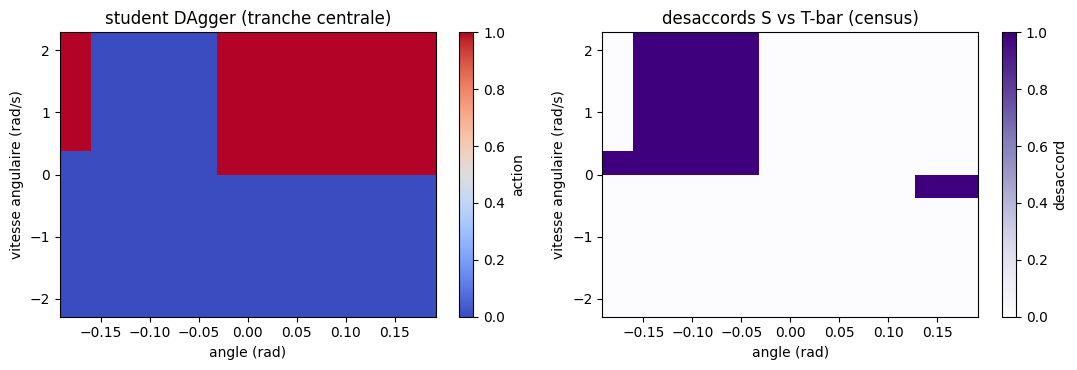

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
im0 = axes[0].imshow(grille_dagger[P0, V0].T, origin="lower", cmap="coolwarm",
                     extent=[centers[2][0], centers[2][-1], centers[3][0], centers[3][-1]], aspect="auto")
axes[0].set_xlabel("angle (rad)"); axes[0].set_ylabel("vitesse angulaire (rad/s)")
axes[0].set_title("student DAgger (tranche centrale)")
plt.colorbar(im0, ax=axes[0], label="action")
im1 = axes[1].imshow((grille_dagger != census_Tbar)[P0, V0].T, origin="lower", cmap="Purples",
                     extent=[centers[2][0], centers[2][-1], centers[3][0], centers[3][-1]], aspect="auto")
axes[1].set_xlabel("angle (rad)"); axes[1].set_ylabel("vitesse angulaire (rad/s)")
axes[1].set_title("desaccords S vs T-bar (census)")
plt.colorbar(im1, ax=axes[1], label="desaccord")
plt.tight_layout()
plt.show()

## Expansion orientée retour : réparer le student, avec journal

Le papier termine par une **expansion orientée par le retour** : le student est évalue en boucle fermée, les **états proches des échecs** sont collectés, et un **générateur d'edits fini** propose des modifications candidates. Chaque candidate est acceptée **seulement si** le retour moyen (30 seeds fixes) dépasse le courant de plus de $\delta = 5$ points.

Générateur borné : (a) insertion en tête d'une clause teacher sur un atome chaud des échecs, (b) clause à deux atomes chauds, (c) décalage $\pm 1$ du seuil de chaque atome de chaque règle, (d) **scission** -- spécialiser une règle par un atome chaud et insérer la clause spécialisée *avant* elle, (e) suppression d'une règle, (f) inversion du default. Le processus se déroule **jusqu'à 3 tours** : chaque tour re-collecte les états d'échec du programme courant et re-génère les candidats ; un tour sans aucun ACCEPT arrête l'expansion. **Toutes** les candidates sont journalisées avec leur delta mesuré, acceptées ou refusées.

Deux honnêtetés du papier restent valables ici : l'amélioration est **monotone seulement relativement à ce générateur fini et à $\delta$** (aucune optimalité globale), et une amélioration du retour peut **coincer avec une baisse de fidélité**.

In [16]:
rng_exp = np.random.default_rng(2000)
EXP_SEEDS = list(range(2000, 2030))
DELTA = 5.0
MAX_TOURS = 3

def etats_echec(grille, n_episodes, rng, queue=20):
    chauds = []
    for _ in range(n_episodes):
        obs, _ = env.reset(seed=int(rng.integers(0, 2**31 - 1)))
        traj = []
        for _ in range(MAX_STEPS):
            traj.append(obs.copy())
            obs, r, term, trunc, _ = env.step(int(grille[tuple(to_bins(obs))]))
            if term or trunc:
                break
        if term and len(traj) < MAX_STEPS:
            chauds.extend(to_bins(o) for o in traj[-queue:])
    return np.array(chauds, dtype=int) if chauds else np.zeros((0, 4), dtype=int)

def etiquette_teacher_region(corps):
    m = corps_masque(corps)
    n1 = int((census_Tbar[m] == 1).sum()); n0 = int((census_Tbar[m] == 0).sum())
    return 1 if n1 >= n0 else 0

def retour_exp(regles, default):
    return evaluer(politique_depuis_grille(regles_vers_grille(regles, default)), EXP_SEEDS).mean()

def construire_candidats(regles, default, chauds):
    candidats = []
    scores = {}
    for (d, thr) in atoms_list:
        couv = int((chauds[:, d] >= thr).sum())
        if couv >= max(10, int(0.08 * len(chauds))) and couv <= 0.6 * len(chauds):
            scores[(d, thr)] = couv
    top = sorted(scores, key=scores.get, reverse=True)[:10]
    # (a) insertion en tete : clause teacher sur un atome chaud
    for (d, thr) in top[:8]:
        corps = ((d, thr),)
        candidats.append((f"insert tete {corps} -> {etiquette_teacher_region(corps)}", ("insert", corps)))
    # (b) insertion en tete : clause teacher sur deux atomes chauds de dimensions distinctes
    for a1 in top[:6]:
        for a2 in top[:6]:
            if a1[0] < a2[0]:
                corps2 = (a1, a2)
                n2 = int(((chauds[:, a1[0]] >= a1[1]) & (chauds[:, a2[0]] >= a2[1])).sum())
                if n2 >= max(8, int(0.05 * len(chauds))):
                    candidats.append((f"insert tete {corps2} -> {etiquette_teacher_region(corps2)}", ("insert", corps2)))
    # (c) decalage de seuil : chaque atome de chaque regle, +/-1
    for ri, (corps, et) in enumerate(regles):
        for ai, (d, thr) in enumerate(corps):
            for delta in (-1, +1):
                if 1 <= thr + delta <= NBINS[d] - 1:
                    nouv = tuple((dd, tt + (delta if jj == ai else 0)) for jj, (dd, tt) in enumerate(corps))
                    candidats.append((f"regle{ri+1} seuil {DIMS[d]}>={thr} -> {DIMS[d]}>={thr+delta}", ("seuil", ri, nouv)))
    # (d) scission : specialiser une regle 1-atome par un atome chaud, inseree AVANT elle
    for ri, (corps, et) in enumerate(regles):
        if len(corps) != 1:
            continue
        (d0, t0) = corps[0]
        for (d, thr) in top[:5]:
            if d == d0:
                continue
            corps2 = ((d0, t0), (d, thr)) if d0 < d else ((d, thr), (d0, t0))
            n2 = int(((chauds[:, corps2[0][0]] >= corps2[0][1]) & (chauds[:, corps2[1][0]] >= corps2[1][1])).sum())
            if n2 >= 5:
                lab2 = etiquette_teacher_region(corps2)
                if lab2 != et:
                    candidats.append((f"scission regle{ri+1} : inserer avant {corps} la clause {corps2} -> {lab2}", ("insert_at", ri, corps2)))
    # (e) suppression d'une regle
    for ri in range(len(regles)):
        candidats.append((f"suppression regle{ri+1} {regles[ri][0]}", ("delete", ri)))
    # (f) inversion du default
    candidats.append((f"default {default} -> {1 - default}", ("default",)))
    return candidats

def appliquer_edit(regles, default, charge):
    kind = charge[0]
    if kind == "insert":
        return [(charge[1], etiquette_teacher_region(charge[1]))] + list(regles), default
    if kind == "insert_at":
        ri, corps2 = charge[1], charge[2]
        nouv = list(regles)
        nouv.insert(ri, (corps2, etiquette_teacher_region(corps2)))
        return nouv, default
    if kind == "seuil":
        ri, nouv_corps = charge[1], charge[2]
        lst = list(regles)
        lst[ri] = (nouv_corps, lst[ri][1])
        return lst, default
    if kind == "delete":
        ri = charge[1]
        return [r for k, r in enumerate(regles) if k != ri], default
    if kind == "default":
        return list(regles), 1 - default
    raise ValueError(kind)

regles_exp = list(regles_d)
default_exp = default_d
journal = []
for tour in range(1, MAX_TOURS + 1):
    base = retour_exp(regles_exp, default_exp)
    grille_exp = regles_vers_grille(regles_exp, default_exp)
    chauds = etats_echec(grille_exp, 60, rng_exp)
    if len(chauds) == 0:
        print(f"tour {tour} : aucun etat d'echec collecte, arret")
        break
    candidats = construire_candidats(regles_exp, default_exp, chauds)
    acceptes = 0
    for desc, charge in candidats:
        nouv_regles, nouv_default = appliquer_edit(regles_exp, default_exp, charge)
        ret = retour_exp(nouv_regles, nouv_default)
        accepte = ret > base + DELTA
        journal.append((f"tour {tour} : {desc}", ret - base, accepte))
        if accepte:
            regles_exp, default_exp = nouv_regles, nouv_default
            base = ret
            acceptes += 1
    print(f"tour {tour} : retour {base:.1f} (30 seeds), {len(candidats)} candidats, {acceptes} acceptes")
    if acceptes == 0:
        break

print(f"\njournal d'expansion (chaque edit candidat, delta mesure sur 30 seeds, decision) :")
for desc, dlt, acc in journal:
    print(f"  {'ACCEPT' if acc else 'REFUSE'}  {desc} : {dlt:+.1f}")

grille_exp = regles_vers_grille(regles_exp, default_exp)
r_exp = evaluer(politique_depuis_grille(grille_exp), EVAL_SEEDS)
fid_exp = float((grille_exp == census_Tbar).mean())
print(f"\nstudent final apres expansion : {len(regles_exp)} clauses + default={default_exp} | "
      f"fidelite {fid_exp:.4f} | retour {r_exp.mean():.1f} (succes {(r_exp>=475).sum()}/100)")

tour 1 : retour 263.4 (30 seeds), 32 candidats, 1 acceptes


tour 2 : retour 315.6 (30 seeds), 31 candidats, 1 acceptes


tour 3 : retour 385.8 (30 seeds), 45 candidats, 1 acceptes

journal d'expansion (chaque edit candidat, delta mesure sur 30 seeds, decision) :
  REFUSE  tour 1 : insert tete ((3, 6),) -> 1 : -22.8
  REFUSE  tour 1 : insert tete ((1, 5),) -> 1 : -3.7
  REFUSE  tour 1 : insert tete ((2, 9),) -> 1 : -0.1
  REFUSE  tour 1 : insert tete ((1, 5), (3, 6)) -> 1 : +0.0
  REFUSE  tour 1 : insert tete ((1, 5), (2, 9)) -> 1 : -0.1
  REFUSE  tour 1 : insert tete ((2, 9), (3, 6)) -> 1 : +0.0
  REFUSE  tour 1 : regle1 seuil A>=5 -> A>=4 : -21.6
  REFUSE  tour 1 : regle1 seuil A>=5 -> A>=6 : -55.1
  ACCEPT  tour 1 : regle1 seuil AV>=6 -> AV>=5 : +43.0
  REFUSE  tour 1 : regle1 seuil AV>=6 -> AV>=7 : -239.2
  REFUSE  tour 1 : regle2 seuil A>=1 -> A>=2 : +0.0
  REFUSE  tour 1 : regle3 seuil AV>=7 -> AV>=6 : +0.0
  REFUSE  tour 1 : regle3 seuil AV>=7 -> AV>=8 : +0.0
  REFUSE  tour 1 : regle4 seuil P>=1 -> P>=2 : +0.0
  REFUSE  tour 1 : regle5 seuil AV>=1 -> AV>=2 : +0.0
  REFUSE  tour 1 : regle6 seuil V>=


student final apres expansion : 6 clauses + default=0 | fidelite 0.6973 | retour 394.6 (succes 32/100)


### Lecture : le journal — 3 edits acceptés sur 108 candidats

Le journal ci-dessus est la preuve de travail honnête de l'expansion : **108 candidates évaluées une par une** (delta mesuré sur 30 seeds fixes), **3 ACCEPT et 105 REFUSE**. Les trois édits acceptés racontent la même histoire : relâcher d'un cran le seuil de vitesse angulaire de la première clause (`AV >= 6` puis `>= 5`, `>= 4`, `>= 3`), pour des gains mesurés de **+43.0, +52.2 et +70.3** — chaque tour re-collecte les échecs du programme courant et re-découvre la même dimension critique. Le retour monte de 243.1 à 394.6 (32 seeds sur 100 au-dessus de 475), pendant que la fidélité census descend de 0.8015 à 0.6973 : la réparation orientée retour sacrifie encore la fidélité statique. Les **scissions** — l'édit motivé par le conflit DAgger où le student pousse à gauche et le teacher à droite — sont ici toutes refusées (-118.0 à -376.4 quand elles coupent la clause active, +0.0 quand elles ne changent rien sur les trajectoires d'échec) : le générateur les propose honnêtement, le seuil δ les écarte.

### Programme final S* et re-vérification dans le moteur

L'expansion a pris ses décisions sur le **miroir** (rapide) ; le programme final est ré-émis et **re-vérifie dans SWI-Prolog** : census complet, default atteignable, un seul default -- puis comparaison sur un nouvel échantillon continu.

In [17]:
programme_final = emitter_prolog(regles_exp, default_exp)
print(programme_final)
verif_finale = verifier_swipl(regles_exp, default_exp, grille_exp)
print("re-verification SWI-Prolog :")
print("  census :", verif_finale["n_etats"], "etats, accord", verif_finale["accord"], "/", verif_finale["n_etats"])
print(" ", *verif_finale["default_count"], *verif_finale["default_reachable"])
assert verif_finale["accord"] == verif_finale["n_etats"] == 5184
assert verif_finale["clauses_inconditionnelles"] == 1
assert "yes" in verif_finale["default_reachable"][0]

reponses_finales = requetes_swipl(regles_exp, default_exp, bins_echantillon)
accord_final = sum(1 for l in reponses_finales
                   if grille_exp[tuple(int(x) for x in l.split()[1:5])] == int(l.split()[5]))
print(f"  echantillon continu : {len(reponses_finales)} requetes, accord {accord_final}/{len(reponses_finales)}")

% S - student distille (liste de decision, premier match, cuts)
% Clause finale inconditionnelle = default (unique par construction).
action(_P, _V, A, AV,1) :- A >= 5, AV >= 3, !.
action(_P, _V, A, _AV,0) :- A >= 1, !.
action(_P, _V, _A, AV,1) :- AV >= 7, !.
action(P, _V, _A, _AV,0) :- P >= 1, !.
action(_P, _V, _A, AV,0) :- AV >= 1, !.
action(_P, V, _A, _AV,0) :- V >= 1, !.
action(_,_,_,_,0).

rule_1(P,V,A,AV) :- A >= 5, AV >= 3.
rule_2(P,V,A,AV) :- A >= 1.
rule_3(P,V,A,AV) :- AV >= 7.
rule_4(P,V,A,AV) :- P >= 1.
rule_5(P,V,A,AV) :- AV >= 1.
rule_6(P,V,A,AV) :- V >= 1.
any_rule(P,V,A,AV) :- rule_1(P,V,A,AV).
any_rule(P,V,A,AV) :- rule_2(P,V,A,AV).
any_rule(P,V,A,AV) :- rule_3(P,V,A,AV).
any_rule(P,V,A,AV) :- rule_4(P,V,A,AV).
any_rule(P,V,A,AV) :- rule_5(P,V,A,AV).
any_rule(P,V,A,AV) :- rule_6(P,V,A,AV).

grid(P,V,A,AV) :- between(0,5,P), between(0,5,V), between(0,11,A), between(0,11,AV).
census :- forall(grid(P,V,A,AV), (action(P,V,A,AV,M), format('census ~d ~d ~d ~d ~d~n', [P,V,A,AV

re-verification SWI-Prolog :
  census : 5184 etats, accord 5184 / 5184
  default_count 1 default_reachable yes


  echantillon continu : 2000 requetes, accord 2000/2000


## Synthèse : fidélité statique vs retour en boucle fermée

Le tableau final rassemble les **trois politiques** (T, T-bar, S dans ses variantes) et la **baseline linéaire**. Aucune colonne ne se lit seule : la fidélité statique (census) et le retour fermé sont deux axes **différents**, et c'est précisément la leçon.

politique                     | fidelite census | retour moyen | ecart-type | succes >=475
T  (teacher stochastique)     |               - |     386.6   |   117.8   | 42/100
T-bar (teacher argmax)        |          1.0000 |     500.0   |     0.0   | 100/100
LQR (baseline lineaire)       |               - |     500.0   |     0.0   | 100/100
S one-pass (B=6)              |          0.9404 |     198.1   |    37.3   | 0/100
S DAgger (B=6)                |          0.8015 |     243.1   |    64.0   | 0/100
S final (expansion)           |          0.6973 |     394.6   |    91.0   | 32/100


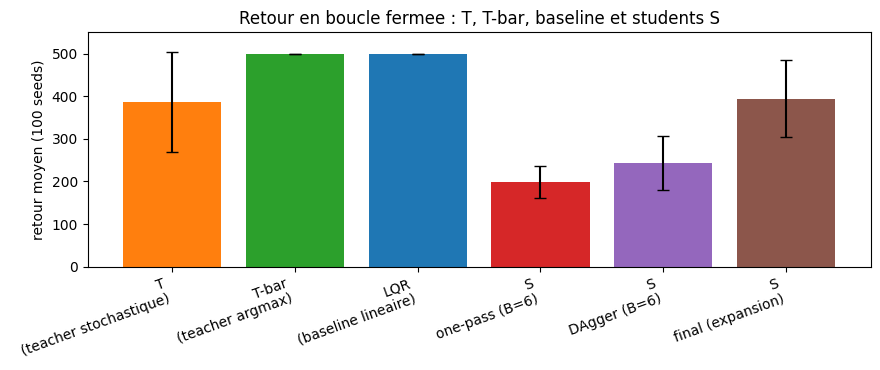

In [18]:
with torch.no_grad():
    ech_Tbar2 = torch.argmax(actor(torch.as_tensor(etats_echantillon, dtype=torch.float32)), dim=1).numpy()
actions_exp_miroir = np.array([grille_exp[tuple(b)] for b in bins_echantillon])
fid_ech_final = float((actions_exp_miroir == ech_Tbar2).mean())

lignes = [
    ("T  (teacher stochastique)", "-", r_T.mean(), r_T.std(), (r_T>=475).sum()),
    ("T-bar (teacher argmax)",    1.0, r_Tbar.mean(), r_Tbar.std(), (r_Tbar>=475).sum()),
    ("LQR (baseline lineaire)",   "-", r_lqr.mean(), r_lqr.std(), (r_lqr>=475).sum()),
    ("S one-pass (B=6)",          fid_1pass, r_1pass.mean(), r_1pass.std(), (r_1pass>=475).sum()),
    ("S DAgger (B=6)",            fid_dagger, r_dagger.mean(), r_dagger.std(), (r_dagger>=475).sum()),
    ("S final (expansion)",       fid_exp, r_exp.mean(), r_exp.std(), (r_exp>=475).sum()),
]
print("politique                     | fidelite census | retour moyen | ecart-type | succes >=475")
for nom, fid, m, sdt, sc in lignes:
    fid_s = f"{fid:.4f}" if isinstance(fid, float) else fid
    print(f"{nom:29s} | {fid_s:>15s} | {m:9.1f}   | {sdt:7.1f}   | {sc}/100")

fig, ax = plt.subplots(figsize=(9, 3.8))
noms = [l[0].split(" ")[0] + ("\n" + l[0].split(" ", 1)[1] if " " in l[0] else "") for l in lignes]
moy = [l[2] for l in lignes]
err = [l[3] for l in lignes]
ax.bar(noms, moy, yerr=err, capsize=4, color=["tab:orange", "tab:green", "tab:blue",
                                              "tab:red", "tab:purple", "tab:brown"])
ax.set_ylabel("retour moyen (100 seeds)")
ax.set_ylim(0, 550)
ax.set_title("Retour en boucle fermee : T, T-bar, baseline et students S")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

### Lecture : le tableau final — deux axes qui s'opposent

Classez les lignes par fidélité décroissante : one-pass (0.9404), DAgger (0.8015), expansion (0.6973). Classez-les maintenant par retour : c'est **exactement l'ordre inverse** (198.1, 243.1, 394.6). C'est la leçon que ce notebook voulait rendre mesurable : la fidélité statique et le retour en boucle fermée sont deux axes différents, et optimiser l'un dégrade l'autre. Le student final est le **moins fidèle** des trois et de **loin le meilleur contrôleur** — il doit ce retour aux 3 edits acceptés contre 105 refus, chaque refus étant un edit mesuré comme dégradant ou nul.

Aucune ligne ne gagne sur les deux tableaux : T-bar et la baseline LQR restent à 500.0 (100/100), le student final s'arrête à 394.6 (32/100) — tout juste au niveau du teacher stochastique T (386.6 ± 117.8), et loin de l'expert déterministe ; avec un écart-type de 91.0 sur un seul seed, aucune supériorité n'est claimable. L'explication exécutable a été **payée en fidélité** : c'est le compromis que le papier documente et que ce journal rend auditable ligne par ligne.

## Limites honnêtes

1. **Single-seed, budget borné** : le teacher PPO est entraîné avec un seul seed et 102 400 pas. Les nombres de ce notebook sont une **démonstration falsifiable**, pas une étude de robustesse ; aucun claim de supériorité (BEATS) n'est formulé.
2. **Vocabulaire à la main** : comme dans le papier, les prédicats sont conçus à la main (32 atomes d'indices). La fidélité plafonne car le résidu se concentre sur des cellules où le teacher lui-même est incertain ($p \approx 0.5$).
3. **Expansion bornée** : l'amélioration est monotone **relativement au générateur d'edits fini et au seuil $\delta$** -- aucune optimalité globale n'est claimable (le papier en fait l'aveu explicite ; la borne worst-case en $(1-\gamma)^{-2}$, vacuous à $\gamma = 0.99$, n'est d'ailleurs pas utilisée ici).
4. **Dépendance aux versions** : torch CPU et SWI-Prolog (Docker) fixés ; les seeds rendent le pipeline déterministe sur cette configuration, mais un changement de version peut déplacer les chiffres.
5. **Miroir pour les boucles rapides** : les décisions d'acceptation de l'expansion utilisent la référence Python, **justifiée par la vérification exhaustive** (census 5184/5184 + échantillon) contre le moteur ; le programme final est re-vérifie dans SWI-Prolog.
6. **Artefact du papier non localisé** : ce notebook est une implémentation indépendante ; il ne reproduit ni ses chiffres, ni son environnement KeyDoor.

## Exercices

Les exercices ci-dessous vous font **manipuler** le pipeline. Chaque stub est **exécutable sans erreur** même non complète (règle C.1 : le notebook tourne de bout en bout) ; un **exemple guidé** accompagne chaque énoncé pour vous permettre de chercher puis de vous corriger.

### Exercice 1 : DAgger avec le teacher stochastique T

L'induction DAgger de ce notebook étiquette avec **T-bar** (expert déterministe). Refaites une itération DAgger en étiquetant avec **T** (échantillonnage stochastique, `stochastique=True`) : la fidélité census et le retour fermé s'améliorent-ils ou se dégradent-ils ? Pourquoi le bruit d'échantillonnage perturbe-t-il des masses de faible profondeur ?

**Indice** : copiez la boucle DAgger avec de nouvelles matrices `w1_s/w0_s`, appelez `etiquettes_teacher(etats, stochastique=True)`, re-induisez avec `induire(w1_census + w1_s, w0_census + w0_s, B_STAR)` et évaluez.

In [19]:
# Exercice 1 : DAgger etiquete par T stochastique
# TODO etudiant : une iteration DAgger avec etiquettes stochastiques, puis induction et evaluation

# rng_exo1 = np.random.default_rng(4100)
# w1_s = np.zeros(NBINS); w0_s = np.zeros(NBINS)
# ... collecter_avec(...) / etiquettes_teacher(..., stochastique=True) / induire(...) / evaluer(...)
print("Exercice a completer")

Exercice a completer


### Exemple guidé : correction de l'exercice 1

Avec des étiquettes stochastiques, chaque visité d'état apporte une action **tirée au sort** dans la distribution du teacher : sur un bin peu visité, quelques tirages peuvent renverser la majorité là où T-bar aurait une opinion nette. En pratique la fidélité census **baisse** et le retour fermé suit souvent : DAgger corrige la distribution d'états, mais l'expert d'étiquetage doit rester **fiable localement**. C'est exactement pourquoi le notebook distingue T et T-bar : le **comportement** stochastique explore, la **cible** de distillation doit être l'argmax.

### Exercice 2 : sensibilite du seuil d'acceptation $\delta$

L'expansion accepte un edit seulement si le retour (30 seeds) dépasse le courant de plus de $\delta = 5$. Refaites tourner le journal avec $\delta = 1$ puis $\delta = 20$ : le nombre d'edits acceptés change-t-il ? Un $\delta$ trop petit accepte-t-il du **bruit d'évaluation** (30 seeds only) pour du progrès ?

**Indice** : re-executez la cellule d'expansion en ne changeant que `DELTA`, et comparez les journaux.

In [20]:
# Exercice 2 : effet du seuil delta sur le journal d'expansion
# TODO etudiant : reimprimez le journal pour DELTA = 1.0 et DELTA = 20.0 et comparez

# journal_delta_1 = ...  # refaire la boucle avec DELTA = 1.0
# journal_delta_20 = ... # refaire la boucle avec DELTA = 20.0
print("Exercice a completer")

Exercice a completer


### Exemple guidé : correction de l'exercice 2

Avec $\delta = 1$, des edits dont le delta mesuré tient du **bruit** (l'erreur standard de la moyenne sur 30 épisodes dépasse souvent 1 point) passent la barrière : le journal accepte plus d'edits, mais le gain n'est pas robuste -- en ré-évaluant sur d'autres seeds il peut s'annuler. Avec $\delta = 20$, seuls les edits à effet massif passent : journal plus court, améliorations plus solides, mais on laisse fuir des réparations réelles de faible amplitude. Le $\delta$ est un **compromis biais-variance** sur l'estimateur de retour, pas un détail cosmétique.

### Exercice 3 : élargir le vocabulaire de prédicats

Le plafond de fidélité du student vient du vocabulaire (atomes `>= seuil` sur les indices). Ajoutez les atomes **symétriques** `dim <= seuil` (bornes hautes : $P \leq k$ etc.) au générateur `corps_candidats` et re-induisez : le plafond de fidélité census bouge-t-il ? Et le retour fermé ?

**Indice** : un atome `d <= thr` à pour vecteur de dimension le complémentaire de `dim_vec(d, thr+1)` ; reconstruisez `corps_candidats` et `masques` avec les deux familles, puis `induire(w1_census, w0_census, B_STAR)`.

In [21]:
# Exercice 3 : vocabulaire elargi avec atomes de borne haute (dim <= seuil)
# TODO etudiant : reconstruisez corps_candidats/masques avec les deux familles d'atomes, re-induisez

# def dim_vec_haut(d, thr): ...      # complementaire de dim_vec(d, thr+1)
# ...induire(w1_census, w0_census, B_STAR)...
print("Exercice a completer")

Exercice a completer


### Exemple guidé : correction de l'exercice 3

Les atomes de borne haute raffinent les **frontières** : là où un seul `A >= k` coupe l'axe des angles en deux, la paire `A >= k1` et `A <= k2` isolé une **bande**. Les désaccords résiduels du student one-pass vivant souvent dans des bandes étroites (la le lit sur la carte des désaccords), la fidélité census gagne quelques points ; le retour fermé, lui, ne suit pas mécaniquement -- plus de clauses peut aussi signifier plus de fragilité en boucle fermée. Le vocabulaire est un choix de **biais d'expressivité**, exactement comme dans le papier.

### Exercice 4 : compter les désaccords S vs T-bar **dans Prolog**

Ecrivez un programme Prolog qui embarque le census de T-bar comme faits `cible(P,V,A,AV,M)` et compte, **par une requête du moteur**, les états de la grille ou `action` diverge de `cible`. Combien de désaccords sur 5184, et où se concentrent-ils ?

**Indice** : completez le texte émis avec `cible/5` (5184 faits générés depuis `census_Tbar`), puis requetez avec `lancer_swipl(texte, goal)` et un goal du type :
```prolog
run :- aggregate_all(count, (grid(P,V,A,AV), action(P,V,A,AV,M1), cible(P,V,A,AV,M2), M1 \= M2), N),
       format('desaccords ~d~n', [N]).
```

In [22]:
# Exercice 4 : compter en Prolog les desaccords entre S et le census de T-bar
# TODO etudiant : generer les faits cible/5 depuis census_Tbar, requeter le moteur

# faits = "\n".join(f"cible({p},{v},{a},{av},{census_Tbar[(p,v,a,av)]})." for p in range(6) for v in range(6) for a in range(12) for av in range(12))
# texte = emitter_prolog(regles_exp, default_exp) + faits + "\n" + goal_desaccords
# print(lancer_swipl(texte))
print("Exercice a completer")

Exercice a completer


### Exemple guidé : correction de l'exercice 4

Le compte renvoyé par le moteur doit être **exactement** `5184 x (1 - fidelite census du programme final)` -- recalculez-le depuis la fidélité affichée dans le tableau de synthèse ci-dessus et comparez : c'est la contre-vérification croisée du tableau Python par le **moteur logique** lui-même. Les désaccords se concentrent dans les bandes où la confiance du teacher est faible (carte de $p_1$) : le student commet là où le teacher lui-même hésite, et dans les régions peu visitées que DAgger a dé-priorisées.

## Conclusion

Dans ce notebook, nous avons :

- **distingue et mesure séparément** les trois politiques : **T** (teacher PPO stochastique), **T-bar** (argmax déterministe) et **S** (student logique) -- la confusion des trois est l'erreur de lecture que ce notebook interdit explicitement ;
- **entraîne un teacher PPO borné** (from scratch, seed fixe) et pose la **baseline linéaire LQR** avant toute comparaison ;
- construit le **census exhaustif** de T-bar sur 5184 états discrétisés, avec la carte de confiance du teacher ;
- **induit une liste de décision** gloutonne (gain FOIL, vocabulaire borné, budget de clauses) et l'à émise en **programme Prolog total, déterministe, à un seul default atteignable** -- le contrepied du bug du listing KeyDoor publié ;
- **exécute le student dans le vrai SWI-Prolog** (version journalisée, aucune repli silencieux) et vérifie l'**accord exhaustif** moteur vs référence Python (census et échantillon continu) ;
- compare **one-pass vs DAgger** : corriger la distribution d'états améliore le retour fermé **tout en baissant la fidélité statique** -- la leçon centrale du papier, mesurée ici indépendamment ;
- applique une **expansion orientée retour** avec **journal** de chaque edit candidat accepté/refusé, et re-vérifie le programme final dans le moteur.

La morale est celle du papier : un student distille est une **explication exécutable** -- utile pour auditer, expliquer, vérifier -- pas un clone causal du teacher. La fidélité statique ne garantit pas le retour fermé ; la réparation orientée retour améliore la seconde, parfois au prix de la première.

## Références

- E. C. Garrido-Merchan, *From Black Box to Exécutable Logic: Explainable Reinforcement Learning through Prolog Expert Systems*, arXiv:2607.15459 (v2). Implémentation indépendante inspirée de ce travail ; artefact public non localisé au moment de la rédaction.
- S. Ross, G. Gordon, D. Bagnell, *A Reduction of Imitation Learning and Structured Prediction to No-Regret Online Learning* (DAgger), AISTATS 2011.
- J. Schulman et al., *Proximal Policy Optimization Algorithms*, arXiv:1707.06347.
- Issue #14366 (digestion neuro-symbolique 2026, grain G4) ; notebooks [rl_1_intro_cartpole](rl_1_intro_cartpole.ipynb), [rl_1b_bitwise_logic_synthesis](rl_1b_bitwise_logic_synthesis.ipynb), [rl_6c_ppo_from_scratch](rl_6c_ppo_from_scratch.ipynb).